Tesla EV Analysis & Forecasting Project
======================================

This script demonstrates an end-to-end Machine Learning pipeline:
1. Import libraries
2. Load dataset
3. Data cleaning
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Train-Test Split
7. Train ML Models
8. Hyperparameter Tuning
9. Model Evaluation
10. Feature Importance
11. Time-Series Forecasting 

In [3]:
# 1. IMPORT LIBRARIES
# ===================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# XGBoost
from xgboost import XGBRegressor

# Time Series Forecasting
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

In [5]:
# 2. LOAD DATASET
# ===============

print("Loading Dataset...")
print("="*25)
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
print("\nFirst Five Records")
print(df.head())
print("\nDataset Information")
print(df.info())
print("\nStatistical Summary")
print(df.describe())

Loading Dataset...

First Five Records
   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Qu

In [6]:
# 3. DATA CLEANING
# ================

print("\nChecking Missing Values")
print(df.isnull().sum())
print("\nRemoving Duplicate Rows...")
df.drop_duplicates(inplace=True)

# Fill missing numeric values
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])
print("\nData Cleaning Completed!") 


Checking Missing Values
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Removing Duplicate Rows...

Data Cleaning Completed!


In [8]:
# 4. ENCODE CATEGORICAL FEATURES
# ==============================

print("\nEncoding Categorical Columns...")
encoder = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])
    print(df[col])


Encoding Categorical Columns...



Performing Exploratory Data Analysis...


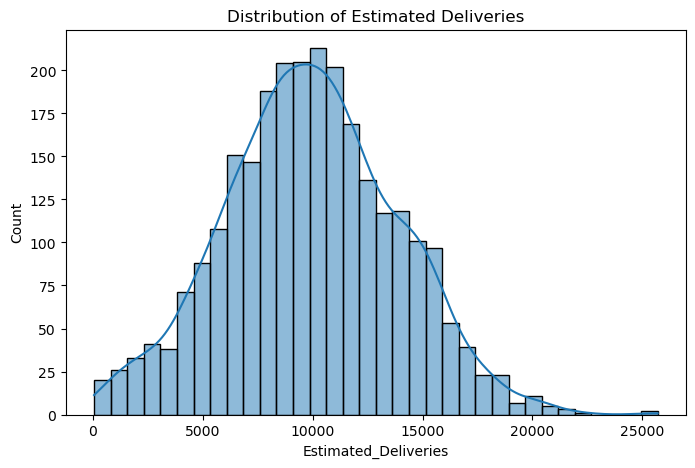

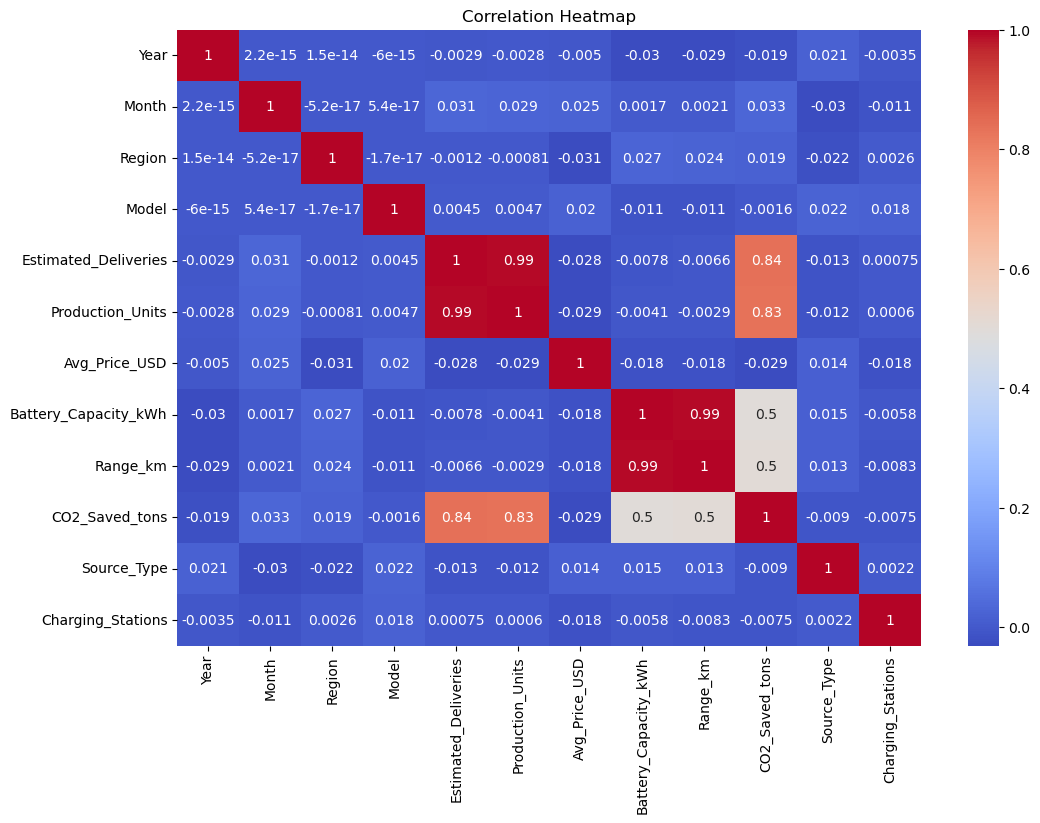

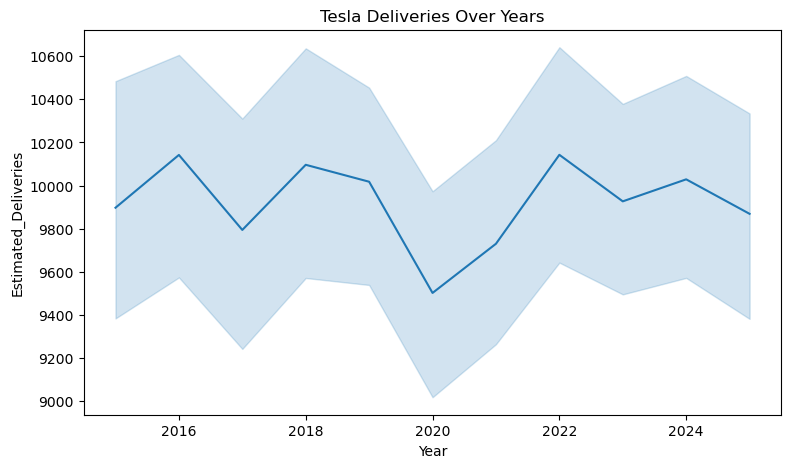

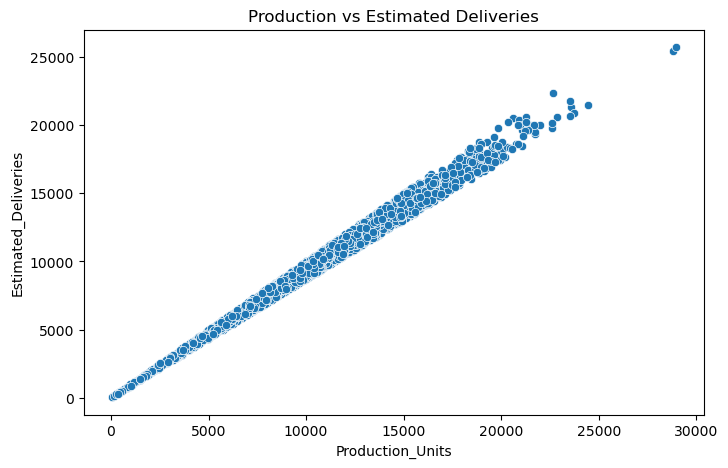

In [9]:
# 5. EXPLORATORY DATA ANALYSIS
# ============================

print("\nPerforming Exploratory Data Analysis...")
plt.figure(figsize=(8,5))
sns.histplot(df["Estimated_Deliveries"], kde=True)
plt.title("Distribution of Estimated Deliveries")
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(9,5))
sns.lineplot(data=df, x="Year", y="Estimated_Deliveries")
plt.title("Tesla Deliveries Over Years")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x="Production_Units",
                y="Estimated_Deliveries")
plt.title("Production vs Estimated Deliveries")
plt.show()

In [10]:
# 6. FEATURE ENGINEERING
# ======================

print("\nCreating New Features...")
df["Production_Efficiency"] = (
    df["Estimated_Deliveries"] /
    df["Production_Units"]
)
df["Price_per_KM"] = (
    df["Avg_Price_USD"] /
    df["Range_km"]
)
print("Feature Engineering Completed!")


Creating New Features...
Feature Engineering Completed!


In [11]:
# 7. PREPARE DATA
# ===============

target = "Estimated_Deliveries"
X = df.drop(target, axis=1)
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.20,random_state=42)

In [12]:
# 8. MODEL TRAINING
# =================

print("\nTraining Linear Regression...")
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print("Training Random Forest...")
rf = RandomForestRegressor(random_state=42)
params = {
    "n_estimators":[100,200,300],
    "max_depth":[5,10,15,None],
    "min_samples_split":[2,5,10]}
search = RandomizedSearchCV(
    rf,params,cv=5,n_iter=10,scoring="r2",random_state=42)
search.fit(X_train, y_train)
best_rf = search.best_estimator_
pred_rf = best_rf.predict(X_test)

print("Training Gradient Boosting...")
gb = GradientBoostingRegressor()
gb.fit(X_train,y_train)
pred_gb = gb.predict(X_test)

print("Training XGBoost...")
xgb = XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=6,random_state=42)
xgb.fit(X_train,y_train)
pred_xgb = xgb.predict(X_test)


Training Linear Regression...
Training Random Forest...
Training Gradient Boosting...
Training XGBoost...


In [15]:
# 9. MODEL EVALUATION
# ===================

def evaluate(name, actual, predicted):
    print("\n")
    print(name)
    print("="*20)
    print("MAE :", mean_absolute_error(actual,predicted))
    print("RMSE:", np.sqrt(mean_squared_error(actual,predicted)))
    print("R² Score:", r2_score(actual,predicted))
evaluate("Linear Regression", y_test, pred_lr)
evaluate("Random Forest", y_test, pred_rf)
evaluate("Gradient Boosting", y_test, pred_gb)
evaluate("XGBoost", y_test, pred_xgb)



Linear Regression
MAE : 108.88658400197407
RMSE: 153.3342321928072
R² Score: 0.998422720227123


Random Forest
MAE : 67.38428331367167
RMSE: 112.91965171174803
R² Score: 0.9991445994047459


Gradient Boosting
MAE : 71.74449604950294
RMSE: 99.77889398447735
R² Score: 0.9993321055117554


XGBoost
MAE : 51.33645248413086
RMSE: 71.47190977383177
R² Score: 0.9996573328971863



Finding Important Features...


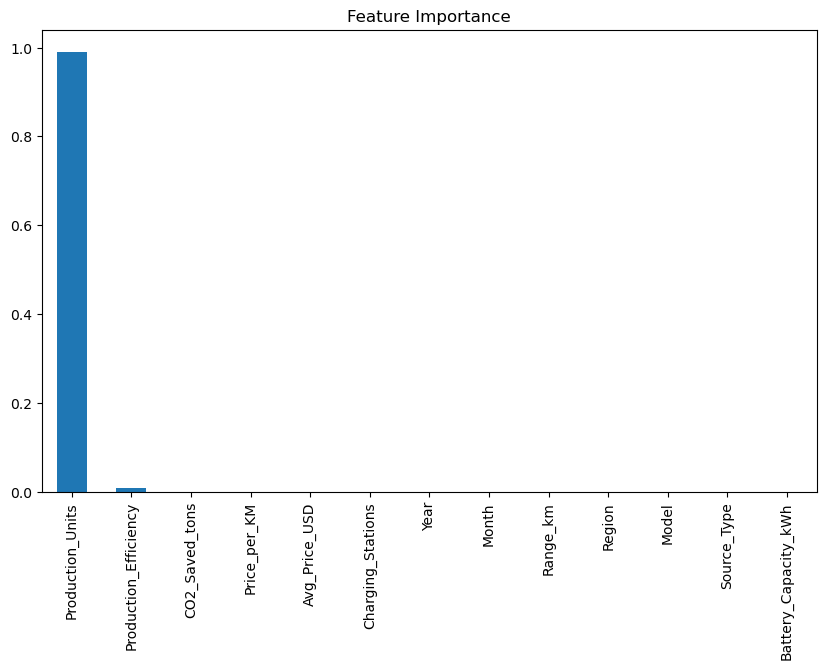

In [16]:
# 10. FEATURE IMPORTANCE
# ======================

print("\nFinding Important Features...")
importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
plt.figure(figsize=(10,6))
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.show()


Forecasting Future Tesla Deliveries...

Forecast for Next Five Years
11    2.367761e+06
12    2.368109e+06
13    2.367415e+06
14    2.367759e+06
15    2.367073e+06
Name: predicted_mean, dtype: float64


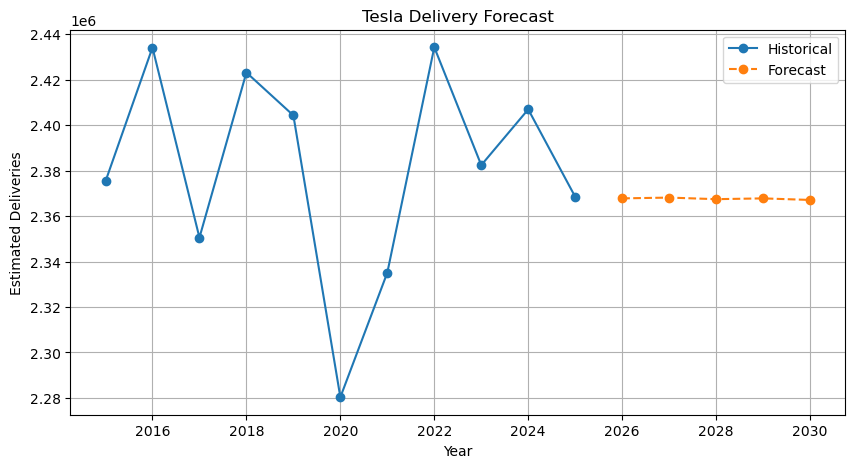


End-to-End Machine Learning Pipeline Completed Successfully!


In [17]:
# 11. TIME SERIES FORECASTING
# ===========================

print("\nForecasting Future Tesla Deliveries...")
ts = df.groupby("Year")["Estimated_Deliveries"].sum()
model = ARIMA(ts, order=(2,1,2))
result = model.fit()
forecast = result.forecast(steps=5)
print("\nForecast for Next Five Years")
print(forecast)
plt.figure(figsize=(10,5))
plt.plot(ts, marker='o', label="Historical")
future_years = range(ts.index.max()+1,ts.index.max()+6)
plt.plot(future_years,forecast,marker='o',linestyle='--',label="Forecast")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")
plt.title("Tesla Delivery Forecast")
plt.legend()
plt.grid(True)
plt.show()
print("\nEnd-to-End Machine Learning Pipeline Completed Successfully!")